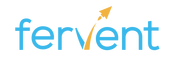
# Minimising Portfolio Risk - Multiple Assets - Applied
In this walkthrough, you'll explore how we can *minimise* the risk of a multi-asset portfolio on Python.

### The risk of a $k$ asset portfolio is calculated as...
$$\sigma_p^2 = var(\mathbf{\Omega'R})$$  
$$\sigma_p^2 = \mathbf{\Omega'\sum\Omega}$$  
$$\sigma_p = \sqrt{\sigma_p^2}$$

Where:  
$\sigma_p^2 = $ The variance of the portfolio  
$\sigma_p = $ The standard deviation (risk) of the portfolio  
$\mathbf{\Omega} = $ Vector of 'weights'  
$\mathbf{\sum} = $ Variance Covariance (VCV) Matrix  
$\mathbf{R} =$ Vector of Returns

In [1]:
# Import package dependencies
import pandas as pd
import numpy as np
from scipy.optimize import minimize

In [2]:
df = pd.read_csv('../data/15stocks_price.csv')  # stock price data

# Convert dates to timestamps and set date column as the index
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'])
df.set_index('date_gsheets', inplace=True)

<div class="alert alert-block alert-info">
<b>Confused by the code in `In[2]` and / or `In[3]`?</b>  

Go back to the lecture on Estimating Portfolio Risk (Multiple Assets) to understand the code before moving on any further.
</div>


In [3]:
def getPortRisk(weights):
    
    '''Returns the annualised standard deviation of a k asset portfolio.'''

    returns_df = df.pct_change(1).dropna()  # estimate returns for each asset
    num_stocks = len(returns_df.columns)  # number of stocks based on number of columns (excluding index col)
                                          # this is a local variable
        
    vcv = returns_df.cov()  # being the variance covariance matrix
    
    var_p = np.dot(np.transpose(weights), np.dot(vcv, weights))  # variance of the multi-asset portfolio
    sd_p = np.sqrt(var_p)  # standard deviation of the multi-asset portfolio
    sd_p_annual = sd_p * np.sqrt(250)  # annualised standard deviation of the multi-asset portfolio
    
    return sd_p_annual

In [4]:
num_stocks = len(df.columns)  # being the number of stocks (this is a 'global' variable)
init_weights = [1 / num_stocks] * num_stocks  # initialise weights (x0)

In [5]:
# Constraint that weights in any asset j must be between 0 and 1 inclusive
bounds = tuple((0, 1) for i in range(num_stocks))

In [6]:
# Constraint that the sum of the weights of all assets must equate to 1
cons = ({'type' : 'eq', 'fun' : lambda x : np.sum(x) - 1})

<div class="alert alert-block alert-info">
<b>Confused by the code in `In[4], In[5]` and / or `In[6]`?</b>  

Go back to the lecture on "Optimising Portfolio Weights - Achieving a Target Return" to understand the code before moving on any further.
</div>


In [7]:
results = minimize(fun=getPortRisk, x0=init_weights, bounds=bounds, constraints=cons)

In [8]:
results

     fun: 0.105934793694922
     jac: array([0.10597393, 0.10585235, 0.10600164, 0.1058007 , 0.10597585,
       0.10618785, 0.10613558, 0.1058246 , 0.10587699, 0.11916338,
       0.11288869, 0.10579355, 0.10934387, 0.1058938 , 0.10634915])
 message: 'Optimization terminated successfully.'
    nfev: 187
     nit: 11
    njev: 11
  status: 0
 success: True
       x: array([4.79798179e-02, 2.80742502e-01, 7.53106175e-03, 1.29294761e-01,
       3.54257634e-02, 8.40457971e-02, 1.62830962e-01, 1.72868279e-01,
       2.00872910e-02, 3.37457926e-18, 0.00000000e+00, 3.55671946e-03,
       0.00000000e+00, 4.31645307e-02, 1.24725153e-02])

In [9]:
# Check total risk of the equal weighted portfolio
getPortRisk(init_weights)

0.13290599867193698

In [10]:
# Explore optimised weights
optimised_weights = pd.DataFrame(results['x'])
optimised_weights.index = df.columns
optimised_weights.rename(columns={optimised_weights.columns[0] : 'weights'}, inplace=True)

In [11]:
optimised_weights

,weights
AAPL,4.797982e-02
KO,2.807425e-01
NFLX,7.531062e-03
BRK.B,1.292948e-01
DIS,3.542576e-02
IBM,8.404580e-02
VZ,1.628310e-01
WMT,1.728683e-01
GE,2.008729e-02
TSLA,3.374579e-18


In [12]:
# Clean format of the weights so it's more readable
optimised_weights['weights_rounded'] = optimised_weights['weights'].apply(lambda x : round(x, 3))

In [13]:
optimised_weights

,weights,weights_rounded
AAPL,4.797982e-02,0.048
KO,2.807425e-01,0.281
NFLX,7.531062e-03,0.008
BRK.B,1.292948e-01,0.129
DIS,3.542576e-02,0.035
IBM,8.404580e-02,0.084
VZ,1.628310e-01,0.163
WMT,1.728683e-01,0.173
GE,2.008729e-02,0.020
TSLA,3.374579e-18,0.000


In [14]:
# Notice how 7 of the 15 stocks make up 92.1% of the portfolio allocation!
optimised_weights['weights_rounded'].sort_values(ascending=False).cumsum()

KO       0.281
WMT      0.454
VZ       0.617
BRK.B    0.746
IBM      0.830
AAPL     0.878
UN       0.921
DIS      0.956
GE       0.976
V        0.988
NFLX     0.996
AMZN     1.000
MSFT     1.000
MA       1.000
TSLA     1.000
Name: weights_rounded, dtype: float64